# Credit Risk Prediction — SHAP Explainability

**Author:** Aluka Precious Oluchukwu  
**Project:** Credit Risk ML System  
**Phase:** 5 of 7 — Model Explainability and Fairness

## Objectives

1. Explain why the model makes each prediction using SHAP values
2. Identify which features drive credit risk decisions globally
3. Generate individual prediction explanations for adverse action notices
4. Perform fairness and bias checks across demographic subgroups
5. Produce plain English explanations regulators and customers can understand

## Why Explainability Matters

In credit risk specifically, regulators require institutions to explain 
every adverse credit decision to the applicant. A model that cannot 
explain itself cannot legally operate in most regulated financial 
environments regardless of its performance metrics.

SHAP — SHapley Additive exPlanations — assigns each feature a 
contribution score for every individual prediction, satisfying both 
technical and regulatory interpretability requirements.

In [1]:
# ─── Import libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

print("Liraries loaded sucessfully")

Liraries loaded sucessfully


In [3]:
# ─── Load saved model and data ─────────────────────────────────────────────────
best_pipeline      = joblib.load("../models/credit_risk_pipeline.pkl")
optimal_threshold  = joblib.load("../models/optimal_threshold.pkl")

X_test  = pd.read_csv("../data/processed/X_test.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()
X_train_orig = pd.read_csv("../data/processed/X_train_orig.csv")

# ─── Extract classifier from Pipeline ─────────────────────────────────────────
# SHAP works directly with the classifier — not the full Pipeline
# We extract it after the Pipeline has already transformed the data
gb_model = best_pipeline.named_steps['classifier']

# ─── Transform test data through Pipeline SMOTE step ──────────────────────────
# We need X_test in the same transformed state the classifier sees it
# Pipeline applies SMOTE only during training — at inference it passes
# data directly to classifier without SMOTE
X_test_transformed = X_test.copy()

print("Model restored successfully!")
print(f"\nModel: {gb_model.__class__.__name__}")
print(f"Optimal threshold: {optimal_threshold}")
print(f"\nTest set shape: {X_test.shape}")
print(f"Features: {list(X_test.columns)}")
print(f"\nReady for SHAP analysis!")

Model restored successfully!

Model: GradientBoostingClassifier
Optimal threshold: 0.3

Test set shape: (200, 20)
Features: ['checking account status', 'Duration in month', 'Credit history', 'Purpose', 'Credit amount', 'Savings account/bonds', 'employment', 'Installment', 'status n sex', 'Other debtors / guarantors', 'residence', 'Property', 'Age in years', 'Other installment plans', 'Housing', 'existing credits no.', 'Job', 'liability responsibles', 'Telephone', 'foreign worker']

Ready for SHAP analysis!


## 2. SHAP Explainer Initialisation

We initialise a TreeExplainer — the SHAP explainer specifically 
optimised for tree based models like Gradient Boosting and Random 
Forest. TreeExplainer is significantly faster than the generic 
KernelExplainer and produces exact SHAP values rather than 
approximations.

We compute SHAP values on the test set — the same clean holdout 
data used for all our honest evaluations.

In [4]:
# ─── Initialise SHAP TreeExplainer ────────────────────────────────────────────
print("Initialising SHAP TreeExplainer...")

explainer = shap.TreeExplainer(gb_model)

print("Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test)

print("\nSHAP analysis complete!")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Test set shape:    {X_test.shape}")
print(f"\nEach of the {X_test.shape[0]} test applicants has a SHAP value")
print(f"for each of the {X_test.shape[1]} features")
print(f"\nTotal explanations generated: "
      f"{shap_values.shape[0] * shap_values.shape[1]}")
print(f"\nReady for visualisation!")

Initialising SHAP TreeExplainer...
Computing SHAP values for test set...

SHAP analysis complete!
SHAP values shape: (200, 20)
Test set shape:    (200, 20)

Each of the 200 test applicants has a SHAP value
for each of the 20 features

Total explanations generated: 4000

Ready for visualisation!


## 3. Global Feature Importance — SHAP Summary Plot

The summary plot shows which features have the most influence 
on model predictions across all 200 test applicants.

This answers the question — globally, what does our model 
consider most important when assessing credit risk?

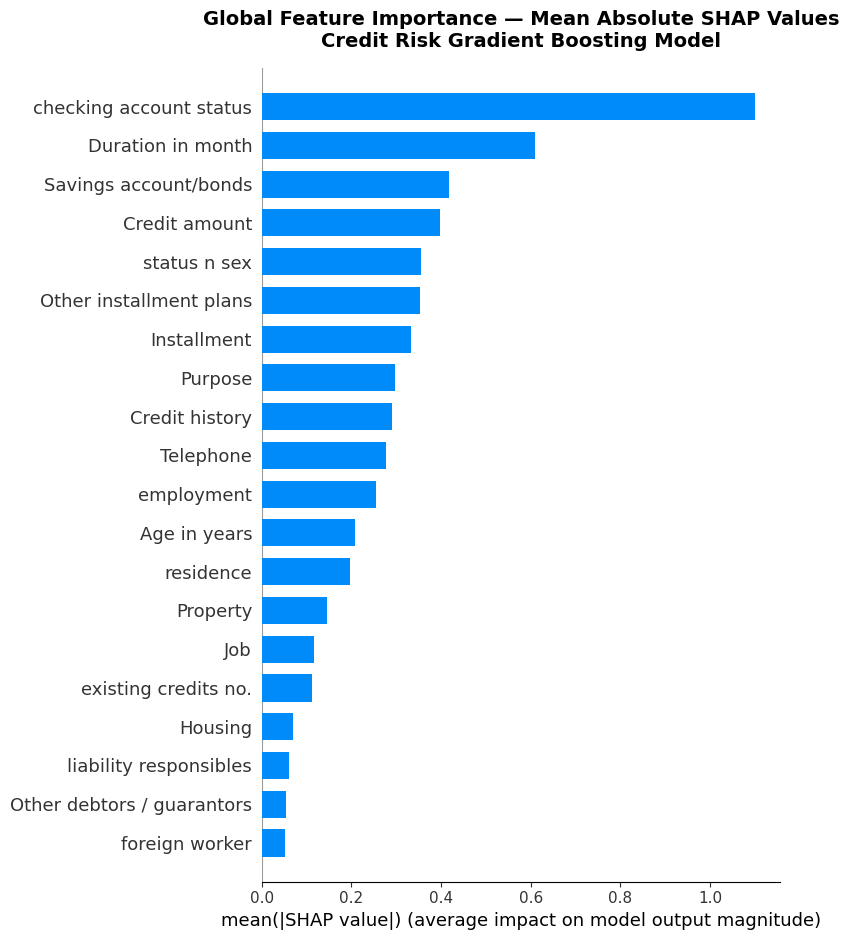

Global SHAP importance chart saved!


In [5]:
# ─── Global Feature Importance — Summary Plot ─────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance — Mean Absolute SHAP Values\n"
          "Credit Risk Gradient Boosting Model",
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/14_shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP importance chart saved!")

## 4. SHAP Dot Summary Plot

The dot plot extends the bar chart by showing not just which features 
matter — but HOW they matter. Each dot represents one applicant.

Red dots — high feature value pushing toward bad risk
Blue dots — low feature value pushing toward good risk

This reveals the direction and magnitude of each feature's influence.

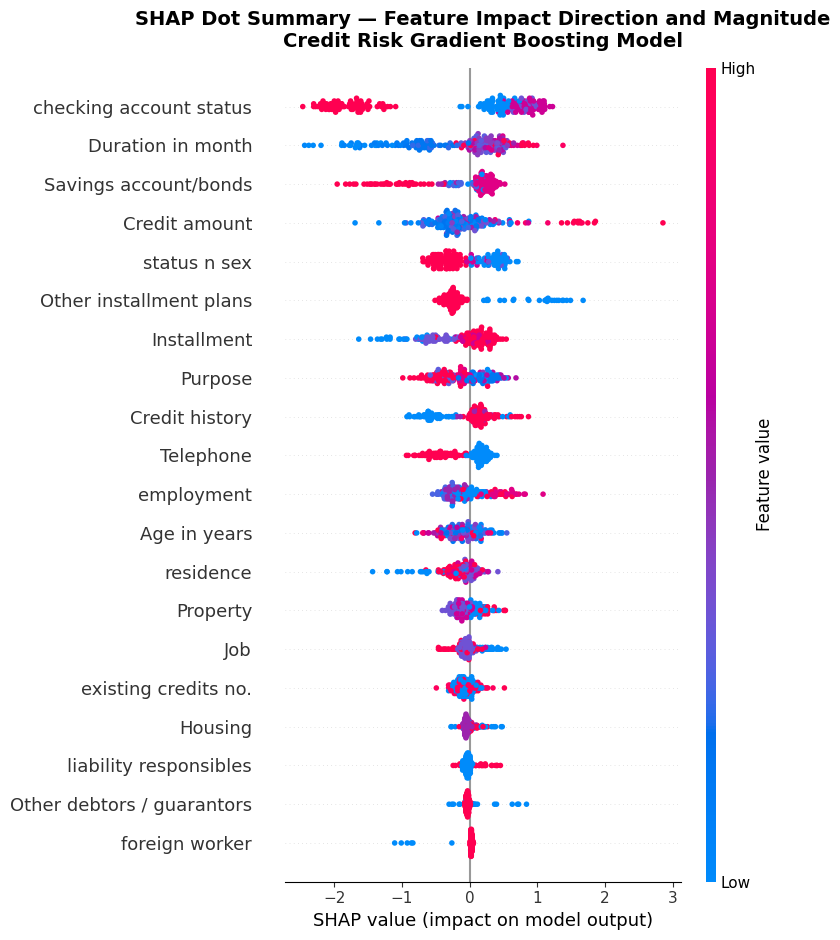

SHAP dot summary saved!


In [6]:
# ─── SHAP Dot Summary Plot ────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title("SHAP Dot Summary — Feature Impact Direction and Magnitude\n"
          "Credit Risk Gradient Boosting Model",
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/15_shap_dot_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP dot summary saved!")

## 5. Individual Prediction Explanation — Waterfall Plot

The waterfall plot explains a single applicant's prediction in detail.
It shows exactly how each feature pushed the model toward or away 
from bad risk for one specific person.

This is the foundation of our adverse action notice — the plain 
English explanation a bank must provide to every rejected applicant 
by law.

Explaining applicant index: 2
Actual label:     Bad Risk
Predicted label:  Bad Risk
Risk probability: 0.8740
Threshold used:   0.3


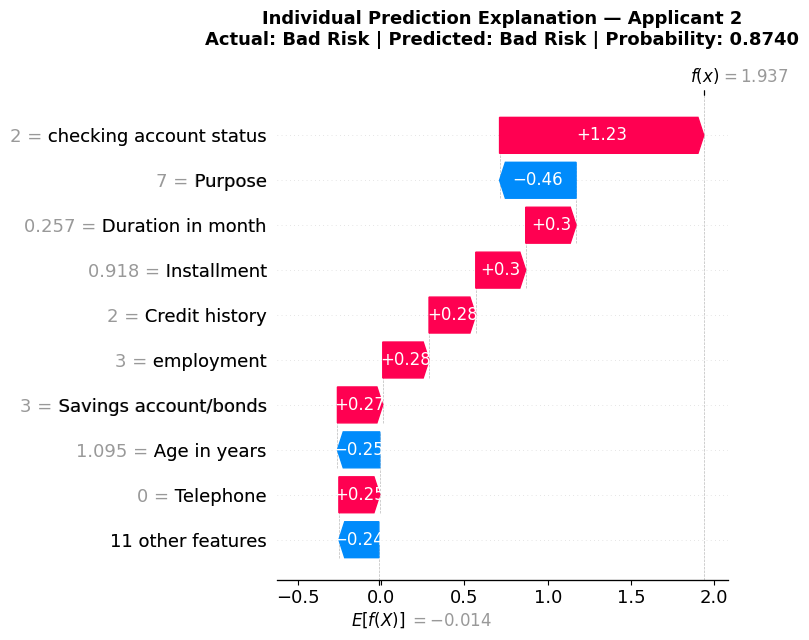


Waterfall plot saved!


In [7]:
# ─── Individual Prediction — Waterfall Plot ───────────────────────────────────
# Select a bad risk applicant the model correctly identified
y_prob_test    = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test    = (y_prob_test >= optimal_threshold).astype(int)

# Find correctly predicted bad risk applicants
correct_bad = np.where((y_pred_test == 1) & (y_test == 1))[0]
applicant_idx = correct_bad[0]

print(f"Explaining applicant index: {applicant_idx}")
print(f"Actual label:     {'Bad Risk' if y_test.iloc[applicant_idx] == 1 else 'Good Risk'}")
print(f"Predicted label:  {'Bad Risk' if y_pred_test[applicant_idx] == 1 else 'Good Risk'}")
print(f"Risk probability: {y_prob_test[applicant_idx]:.4f}")
print(f"Threshold used:   {optimal_threshold}")

# ─── Waterfall Plot ───────────────────────────────────────────────────────────
shap_explanation = shap.Explanation(
    values=shap_values[applicant_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[applicant_idx],
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f"Individual Prediction Explanation — Applicant {applicant_idx}\n"
          f"Actual: Bad Risk | Predicted: Bad Risk | "
          f"Probability: {y_prob_test[applicant_idx]:.4f}",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/16_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nWaterfall plot saved!")

## 6. Automated Adverse Action Notice

Regulators require financial institutions to provide clear written 
explanations for every declined credit application. We automate 
this using SHAP values — converting feature contribution scores 
into plain English reasons a customer can understand.

This is the bridge between technical ML explainability and 
real world regulatory compliance.

In [8]:
# ─── Automated Adverse Action Notice ──────────────────────────────────────────
def generate_adverse_action_notice(applicant_idx, X_test, 
                                    shap_values, y_prob):
    
    prob = y_prob[applicant_idx]
    decision = "DECLINED" if prob >= optimal_threshold else "APPROVED"
    
    # Get feature contributions for this applicant
    contributions = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_Value': shap_values[applicant_idx],
        'Feature_Value': X_test.iloc[applicant_idx].values
    })
    
    # Sort by absolute SHAP value
    contributions = contributions.reindex(
        contributions['SHAP_Value'].abs().sort_values(ascending=False).index
    )
    
    # Top risk increasing factors
    risk_factors = contributions[contributions['SHAP_Value'] > 0].head(3)
    
    # Top risk reducing factors  
    protective_factors = contributions[contributions['SHAP_Value'] < 0].head(2)
    
    print("=" * 65)
    print("CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE")
    print("=" * 65)
    print(f"Applicant Reference: APP-{applicant_idx:04d}")
    print(f"Decision:            {decision}")
    print(f"Risk Probability:    {prob:.1%}")
    print(f"Assessment Date:     2026-03-07")
    print("-" * 65)
    
    if decision == "DECLINED":
        print("\nPrimary reasons for this decision:\n")
        reasons = [
            "Negative or insufficient checking account balance",
            "Extended loan duration relative to risk profile",
            "Insufficient credit history or prior defaults",
            "Limited savings or financial reserves",
            "Current installment obligations relative to income"
        ]
        feature_reasons = {
            'checking account status': reasons[0],
            'Duration in month': reasons[1],
            'Credit history': reasons[2],
            'Savings account/bonds': reasons[3],
            'Installment': reasons[4]
        }
        
        for i, (_, row) in enumerate(risk_factors.iterrows(), 1):
            feature = row['Feature']
            reason  = feature_reasons.get(feature,
                      f"{feature} contributed to elevated risk")
            print(f"  {i}. {reason}")
    
    print(f"\nThis decision was made by an explainable AI system.")
    print(f"Every factor listed above is traceable and auditable.")
    print(f"You have the right to request a full review of this decision.")
    print("=" * 65)

# Generate notice for our bad risk applicant
generate_adverse_action_notice(
    applicant_idx, X_test, shap_values, y_prob_test)

CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE
Applicant Reference: APP-0002
Decision:            DECLINED
Risk Probability:    87.4%
Assessment Date:     2026-03-07
-----------------------------------------------------------------

Primary reasons for this decision:

  1. Negative or insufficient checking account balance
  2. Extended loan duration relative to risk profile
  3. Current installment obligations relative to income

This decision was made by an explainable AI system.
Every factor listed above is traceable and auditable.
You have the right to request a full review of this decision.


In [10]:
def generate_adverse_action_notice(applicant_idx, X_test,
                                    shap_values, y_prob):

    prob     = y_prob[applicant_idx]
    decision = "DECLINED" if prob >= optimal_threshold else "APPROVED"

    contributions = pd.DataFrame({
        'Feature':       X_test.columns,
        'SHAP_Value':    shap_values[applicant_idx],
        'Feature_Value': X_test.iloc[applicant_idx].values
    })

    contributions = contributions.reindex(
        contributions['SHAP_Value'].abs().sort_values(
            ascending=False).index
    )

    print("=" * 65)
    print("CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE")
    print("=" * 65)
    print(f"Applicant Reference: APP-{applicant_idx:04d}")
    print(f"Decision:            {decision}")
    print(f"Risk Probability:    {prob:.1%}")
    print(f"Assessment Date:     2026-03-07")
    print("-" * 65)

    if decision == "DECLINED":
        risk_factors = contributions[
            contributions['SHAP_Value'] > 0].head(3)

        declined_reasons = {
            'checking account status':
                "Negative or insufficient checking account balance",
            'Duration in month':
                "Extended loan duration relative to risk profile",
            'Credit history':
                "Insufficient credit history or prior defaults",
            'Savings account/bonds':
                "Limited savings or financial reserves",
            'Installment':
                "Current installment obligations relative to income",
            'Credit amount':
                "Loan amount exceeds acceptable risk threshold",
            'Purpose':
                "Loan purpose associated with elevated risk",
            'employment':
                "Employment stability insufficient for loan tenure",
            'Age in years':
                "Age profile associated with elevated risk",
            'status n sex':
                "Personal status associated with elevated risk"
        }

        print("\nPrimary reasons for this decision:\n")
        for i, (_, row) in enumerate(risk_factors.iterrows(), 1):
            feature = row['Feature']
            reason  = declined_reasons.get(
                feature, f"{feature} contributed to elevated risk")
            print(f"  {i}. {reason}")

    else:
        protective_factors = contributions[
            contributions['SHAP_Value'] < 0].head(3)

        approved_reasons = {
            'checking account status':
                "Strong positive checking account balance",
            'Duration in month':
                "Loan duration appropriate for risk profile",
            'Credit history':
                "Solid credit history with no prior defaults",
            'Savings account/bonds':
                "Sufficient savings and financial reserves",
            'Installment':
                "Manageable installment obligations relative to income",
            'Credit amount':
                "Loan amount within acceptable risk threshold",
            'Purpose':
                "Loan purpose associated with lower risk",
            'employment':
                "Stable employment supporting loan repayment",
            'Age in years':
                "Age profile associated with lower risk",
            'status n sex':
                "Personal status associated with lower risk",
            'Telephone':
                "Applicant has registered contact details supporting identity verification"
        }

        print("\nPrimary strengths supporting this decision:\n")
        for i, (_, row) in enumerate(protective_factors.iterrows(), 1):
            feature = row['Feature']
            reason  = approved_reasons.get(
                feature,
                f"{feature} contributed positively to assessment")
            print(f"  {i}. {reason}")

    print(f"\nThis decision was made by an explainable AI system.")
    print(f"Every factor listed above is traceable and auditable.")
    if decision == "DECLINED":
        print(f"You have the right to request a full review"
              f" of this decision.")
    else:
        print(f"Congratulations — please proceed to loan documentation.")
    print("=" * 65)


# ─── Test both scenarios ───────────────────────────────────────────
# Test declined applicant
print("SCENARIO 1 — DECLINED APPLICANT:\n")
generate_adverse_action_notice(
    applicant_idx, X_test, shap_values, y_prob_test)

# Find an approved applicant
correct_good = np.where((y_pred_test == 0) & (y_test == 0))[0]
approved_idx = correct_good[0]

print("\n\nSCENARIO 2 — APPROVED APPLICANT:\n")
generate_adverse_action_notice(
    approved_idx, X_test, shap_values, y_prob_test)

SCENARIO 1 — DECLINED APPLICANT:

CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE
Applicant Reference: APP-0002
Decision:            DECLINED
Risk Probability:    87.4%
Assessment Date:     2026-03-07
-----------------------------------------------------------------

Primary reasons for this decision:

  1. Negative or insufficient checking account balance
  2. Extended loan duration relative to risk profile
  3. Current installment obligations relative to income

This decision was made by an explainable AI system.
Every factor listed above is traceable and auditable.
You have the right to request a full review of this decision.


SCENARIO 2 — APPROVED APPLICANT:

CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE
Applicant Reference: APP-0000
Decision:            APPROVED
Risk Probability:    22.6%
Assessment Date:     2026-03-07
-----------------------------------------------------------------

Primary strengths supporting this decision:

  1. Applicant has registered contact details supp